In [1]:
from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.metrics import mae, rmse, poisson_deviance
from modeling.models import build_model
from modeling.split import make_split
from modeling.evaluate import _load_run
import pickle
from types import SimpleNamespace
from omegaconf import DictConfig, OmegaConf

In [2]:
cfg = OmegaConf.create({'load_model': 'ward3_xgb_20200601_20251231_20260320_c5742727'})
model_path, run_cfg = _load_run(cfg)
with open(model_path, "rb") as f:
    saved = pickle.load(f)
model = saved["model"]
feature_cols = saved["feature_cols"]
feat_params = SimpleNamespace(**saved["feat_params"])

In [3]:
pothole_df, weather_df = build_daily(run_cfg)
feat_df = assemble_features(pothole_df, weather_df, feat_params)
feat_df = make_split(feat_df, run_cfg.split)


[assemble_features] kept 1815/1826 rows (99.4%) after dropping NaNs


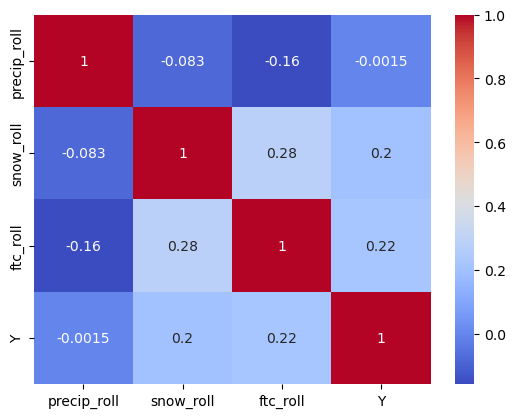

In [4]:
# get correlation matrix for precip, snow, ftc: 
import seaborn as sns
import matplotlib.pyplot as plt

# Create a correlation matrix
sns.heatmap(feat_df[['precip_roll', 'snow_roll', 'ftc_roll', 'Y']].corr(), annot=True, cmap='coolwarm')
plt.show()



In [5]:
test_df = feat_df[feat_df["split"] == "test"]
X_test = test_df[feature_cols]
y_test = test_df["Y"]

In [6]:
train_val_df = feat_df[feat_df["split"].isin(["train", "val"])] # get the train and val set
X_tv = train_val_df[feature_cols]
y_tv = train_val_df["Y"] # get the target for the train and val set

In [7]:
model.predict(X_test, recursive = True)

Using recursive prediction with k_AR = {k_AR}


array([2.9163692 , 4.693941  , 3.4435265 , 2.5300925 , 2.8809044 ,
       3.5088785 , 3.234043  , 3.5513718 , 1.48828   , 1.4898696 ,
       1.5085124 , 2.1306016 , 1.945012  , 1.9810553 , 2.002602  ,
       1.0217552 , 1.7037317 , 2.1496923 , 2.1572282 , 2.4471357 ,
       2.3672667 , 2.2278433 , 0.8415724 , 1.8567983 , 2.13214   ,
       2.0542426 , 1.6839223 , 2.039935  , 1.7911677 , 0.82925606,
       1.2127042 , 1.8302718 , 1.7670815 , 1.7950639 , 1.610961  ,
       1.7919393 , 1.0396262 , 1.1593013 , 1.9382311 , 1.9504412 ,
       1.8120087 , 1.5162867 , 2.2947218 , 0.6788483 , 1.1131959 ,
       2.32935   , 2.124294  , 1.6428628 , 2.306541  , 1.9855466 ,
       0.71908593, 1.4603053 , 2.0898528 , 2.7686393 , 1.7424634 ,
       2.23777   , 2.0225747 , 0.8482944 , 1.2847004 , 1.7277879 ,
       1.709238  , 1.2723128 , 1.6876509 , 1.4435853 , 0.8408509 ,
       0.86070126, 1.9557027 , 1.2526944 , 1.152883  , 1.1521747 ,
       1.111823  , 0.95251644, 0.6198077 , 1.3231732 , 1.16165

In [8]:
# predict on the test set: 
y_test_preds = model.predict(X_test, recursive = True)
# predict on the train and val set: 
y_train_preds = model.predict(X_tv, recursive = True)


Using recursive prediction with k_AR = {k_AR}
Using recursive prediction with k_AR = {k_AR}


In [9]:
# append trains and predicteds: 
import numpy as np
y_true = np.concatenate([y_tv.values, y_test.values], axis=0)
y_pred_full = np.concatenate([y_train_preds, y_test_preds], axis=0)


# plot the residuals: 


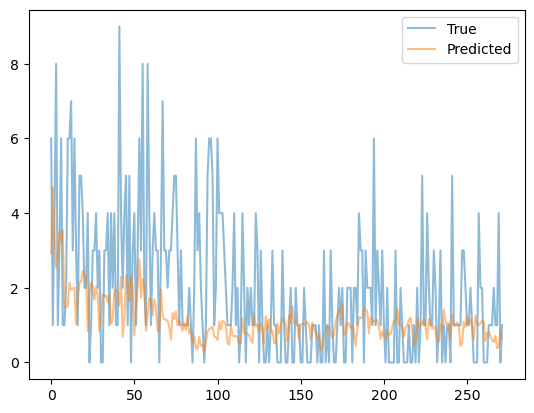

In [10]:
plt.plot(y_test.values, alpha=0.5, label='True')
plt.plot(y_test_preds, alpha=0.5, label='Predicted')
plt.legend()
plt.show()

In [44]:
model.seasonal_order

(0, 0, 1, 7)

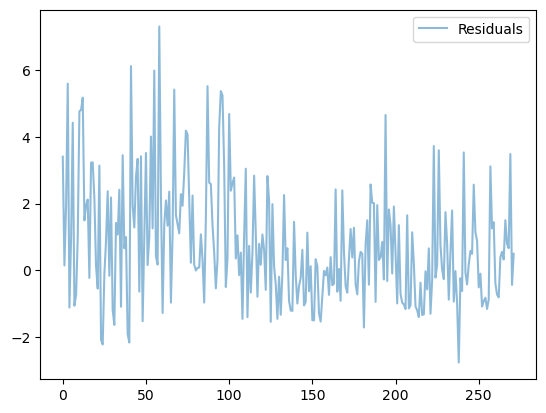

In [11]:
residuals = y_true - y_pred_full
plt.plot(residuals[-272:], alpha=0.5, label='Residuals')
plt.legend()
plt.show()


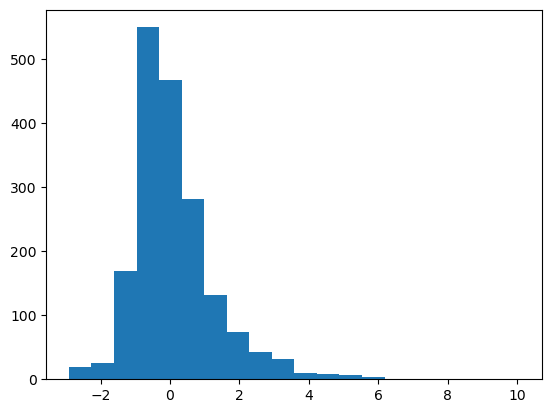

In [12]:
# distribution of residuals: 
z_residuals = (residuals - residuals.mean()) / residuals.std()
plt.hist(residuals, bins=20)
plt.show()
